# Evolutionary Feature Selection Using Genetic Algorithms for Optimizing Multiple Machine Learning Models

In [1]:
#Import numpy and pandas
import numpy as np
import pandas as pd

In [2]:
#load dataset
columns = [
    'age','workclass','fnlwgt','education',
    'education_num','marital_status',
    'occupation','relationship',
    'race','sex',
    'capital_gain','capital_loss',
    'hours_per_week','native_country',
    'income'
]
df = pd.read_csv(
    r"C:\Users\reju6\Downloads\adult (1)\adult.data",
    names=columns,
    skipinitialspace=True
)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
#dataset information
df.info()
#dataset column + rows
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


(32561, 15)

In [4]:
#check missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [5]:
#target variable is income (O/P) according to the dataset counts the income <=50k
df['income'].value_counts

<bound method IndexOpsMixin.value_counts of 0        <=50K
1        <=50K
2        <=50K
3        <=50K
4        <=50K
         ...  
32556    <=50K
32557     >50K
32558    <=50K
32559    <=50K
32560     >50K
Name: income, Length: 32561, dtype: object>

In [6]:
#handle missing values
df=df.replace("?",np.nan)
df.isnull().sum()
df=df.dropna()

In [7]:
#split features and target
x=df.drop("income",axis=1)   #features without income column like age, race
y=df['income']        #target with only income column

In [8]:
#categorical columns which has object data type
categorical_cols=x.select_dtypes(include=["object"]).columns
categorical_cols

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country'],
      dtype='object')

In [9]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
for cols in categorical_cols:
    x[cols]=le.fit_transform(x[cols])   #label encoding categorical columns (text->numbers)

y=le.fit_transform(y)  #encode target variable

In [10]:
#train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,  #80%->training data 20%->testing data
    random_state=42
)

In [11]:
#Random Forest baseline model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score
import time

#start timer(training time of model starts)
rf_baseline_start=time.time()

rf_model=RandomForestClassifier(   #create the model
    random_state=42
)
rf_model.fit(x_train,y_train)  #train the model
rf_predictions=rf_model.predict(x_test)
rf_baseline_end=time.time()    #end timer
rf_baseline_time=rf_baseline_end - rf_baseline_start

#calculate performance metrics
rf_baseline_accuracy=accuracy_score(y_test,rf_predictions)
rf_baseline_precision=precision_score(y_test,rf_predictions)
rf_baseline_f1=f1_score(y_test,rf_predictions)
rf_baseline_recall=recall_score(y_test,rf_predictions)

#display results
print("Random Forest baseline performance")
print("------------------------------------")
print("Number of Features:", x_train.shape[1])
print("Accuracy:", rf_baseline_accuracy)
print("Precision:", rf_baseline_precision)
print("Recall:", rf_baseline_recall)
print("F1 Score:", rf_baseline_f1)
print("Training Time:", rf_baseline_time)


Random Forest baseline performance
------------------------------------
Number of Features: 14
Accuracy: 0.8552958727001492
Precision: 0.7486752460257381
Recall: 0.64640522875817
F1 Score: 0.6937916520519116
Training Time: 5.0623557567596436


In [12]:
#number of features in baseline random forest model
import pygad
rf_num_features=x_train.shape[1]
rf_num_features

14

In [13]:
#Random forest fitness function
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def rf_fitness_func(ga_instance,solution,solution_idx):
    selected_features=[ i for i in range(rf_num_features)
                        if solution[i]==1
                      ]
    if len(selected_features)==0:
        return 0
    x_train_selected=x_train.iloc[:,selected_features]
    x_test_selected=x_test.iloc[:,selected_features]
    
    model=RandomForestClassifier(
     random_state=42,
     n_estimators=100
    )
    model.fit(x_train_selected,y_train)
    predictions=model.predict(x_test_selected)
    accuracy=accuracy_score(y_test,predictions)
    
    return accuracy
    

In [14]:
# random forest genetic algorithm
rf_ga=pygad.GA(
    num_generations=20,
    num_parents_mating=4,
    fitness_func=rf_fitness_func,
    sol_per_pop=10,
    num_genes=rf_num_features,
    gene_type=int,
    gene_space=[0,1],
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    random_seed=42
)

In [15]:
#run the GA
rf_ga.run()

In [16]:
#get the best solution
rf_solution,rf_solution_fitness,rf_solution_idx=rf_ga.best_solution()
print("Best fitness:",rf_solution_fitness)
print("Best chromosomes:",rf_solution)

Best fitness: 0.8624233383059837
Best chromosomes: [0 1 0 0 1 1 1 0 0 1 1 1 0 0]


In [17]:
rf_selected_feature_indices=[ 
    i for i in range(rf_num_features)
    if rf_solution[i]==1
]
rf_selected_feature_names=x_train.columns[rf_selected_feature_indices]
print("selected features:")
print(rf_selected_feature_names)

selected features:
Index(['workclass', 'education_num', 'marital_status', 'occupation', 'sex',
       'capital_gain', 'capital_loss'],
      dtype='object')


In [18]:
#train and test data by getting the selected features from genetic algorithm
x_train_rf=x_train.iloc[:,rf_selected_feature_indices]
x_test_rf=x_test.iloc[:,rf_selected_feature_indices]

In [19]:
#optimized random forest model
rf_optimized_start=time.time()
rf_optimized_model=RandomForestClassifier(
    random_state=42
)
rf_optimized_model.fit(x_train_rf,y_train)
rf_optimized_predictions=rf_optimized_model.predict(x_test_rf)
rf_optimized_end=time.time()
rf_optimized_time=rf_optimized_end-rf_optimized_start   #training time

# calculate performance metrics 
rf_optimized_accuracy=accuracy_score(y_test,rf_optimized_predictions)
rf_optimized_precision=precision_score(y_test,rf_optimized_predictions)
rf_optimized_recall=recall_score(y_test,rf_optimized_predictions)
rf_optimized_f1=f1_score(y_test,rf_optimized_predictions)

#display results
print("Optimized Random Forest Performance")
print("-----------------------------------")
print("Number of Features:", x_train_rf.shape[1])
print("Accuracy:", rf_optimized_accuracy)
print("Precision:", rf_optimized_precision)
print("Recall:", rf_optimized_recall)
print("F1 Score:", rf_optimized_f1)
print("Training Time:", rf_optimized_time)


Optimized Random Forest Performance
-----------------------------------
Number of Features: 7
Accuracy: 0.8624233383059837
Precision: 0.7623688155922039
Recall: 0.6647058823529411
F1 Score: 0.710195530726257
Training Time: 2.1061830520629883


In [20]:
#hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
rf_param_grid = {                            #set where the RandomizedSearchCV will test
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],     
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
#create the search object
rf_random_search=RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20,               #tests 20 random parameter combinations
    cv=5,                   #Uses 5-fold cross-validation, which gives a more reliable estimate of performance.
    scoring='accuracy',       #chooses combination with the highest accuracy
    random_state=42,
    n_jobs=-1               #Uses all available CPU cores to speed up the search.
)

rf_tuning_start=time.time()
rf_random_search.fit(x_train_rf,y_train)
rf_tuning_end=time.time()
rf_tuning_time=rf_tuning_end - rf_tuning_start
print("best parameters:",rf_random_search.best_params_)

#get the best model
rf_final_model=rf_random_search.best_estimator_

rf_final_predictions=rf_final_model.predict(x_test_rf)

#calculate performace metrics
rf_final_accuracy=accuracy_score(y_test,rf_final_predictions)
rf_final_precision=precision_score(y_test,rf_final_predictions)
rf_final_recall=recall_score(y_test,rf_final_predictions)
rf_final_f1=f1_score(y_test,rf_final_predictions)

#display final performance metrics
print("Final Tuned Random Forest")
print("-------------------------")
print("Accuracy:", rf_final_accuracy)
print("Precision:", rf_final_precision)
print("Recall:", rf_final_recall)
print("F1 Score:", rf_final_f1)
print("Hyperparameter Tuning Time:", rf_tuning_time)

best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
Final Tuned Random Forest
-------------------------
Accuracy: 0.8634178683905188
Precision: 0.786525974025974
Recall: 0.6333333333333333
F1 Score: 0.7016654598117307
Hyperparameter Tuning Time: 51.173728942871094


In [21]:
#best parameters for final random forest after tuning
best_rf_params=rf_random_search.best_params_
best_rf_params

{'n_estimators': 200,
 'min_samples_split': 5,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 20}

In [22]:
#Baseline Logistic Regression model
from sklearn.linear_model import LogisticRegression
lr_baseline_start=time.time()
lr_model=LogisticRegression(
    max_iter=2000,
    random_state=42
)
lr_model.fit(x_train,y_train)
lr_predictions=lr_model.predict(x_test)
lr_baseline_end=time.time()
lr_baseline_time=lr_baseline_end-lr_baseline_start
lr_accuracy=accuracy_score(y_test,lr_predictions)
lr_precision=precision_score(y_test,lr_predictions)
lr_f1=f1_score(y_test,lr_predictions)
lr_recall=recall_score(y_test,lr_predictions)
print("Baseline Logistic Regression")
print("----------------------------")
print("Number of Features:", x_train.shape[1])
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)
print("Training Time:", lr_baseline_time)

Baseline Logistic Regression
----------------------------
Number of Features: 14
Accuracy: 0.8029172882479695
Precision: 0.7092024539877301
Recall: 0.37777777777777777
F1 Score: 0.4929637526652452
Training Time: 4.771253824234009


C:\Users\reju6\.anaconda\anacondadestinationfolder\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
#feature scaling for logistic regression and using it for GA
from sklearn.preprocessing import StandardScaler
lr_scaler=StandardScaler()
x_train_lr_scaled=lr_scaler.fit_transform(x_train)
x_test_lr_scaled=lr_scaler.transform(x_test)
lr_model_scaled=LogisticRegression(
    max_iter=2000,
    random_state=42
)
lr_model_scaled.fit(x_train_lr_scaled,y_train)
lr_scaled_predictions=lr_model_scaled.predict(x_test_lr_scaled)

lr_scaled_accuracy=accuracy_score(y_test,lr_scaled_predictions)
lr_scaled_precision=precision_score(y_test,lr_scaled_predictions)
lr_scaled_f1=f1_score(y_test,lr_scaled_predictions)
lr_scaled_recall=recall_score(y_test,lr_scaled_predictions)

print("scaled Logistic Regression")
print("----------------------------")
print("Accuracy:", lr_scaled_accuracy)
print("Precision:", lr_scaled_precision)
print("Recall:", lr_scaled_recall)
print("F1 Score:", lr_scaled_f1)


scaled Logistic Regression
----------------------------
Accuracy: 0.8229736449527598
Precision: 0.7441860465116279
Recall: 0.46013071895424834
F1 Score: 0.568659127625202


In [24]:
#number of features
lr_num_features=x_train_lr_scaled.shape[1]
lr_num_features

14

In [25]:
#fitness function for logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def lr_fitness_function(ga_instance, solution, solution_idx):
    selected_features = [
        i for i in range(lr_num_features)
        if solution[i] == 1
    ]
    if len(selected_features) == 0:
        return 0

    x_train_selected = x_train_lr_scaled[:, selected_features]
    x_test_selected = x_test_lr_scaled[:, selected_features]
    model = LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        random_state=42
    )
    model.fit(x_train_selected, y_train)
    predictions = model.predict(x_test_selected)
    accuracy = accuracy_score(y_test, predictions)

    return accuracy

In [26]:
#Genetic algorithm
lr_ga = pygad.GA(
    num_generations=20,
    num_parents_mating=4,
    fitness_func=lr_fitness_function,
    sol_per_pop=10,
    num_genes=lr_num_features,
    gene_type=int,
    gene_space=[0, 1],
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    random_seed=42
)

In [27]:
lr_ga.run()

In [28]:
#get the best solution
lr_solution,lr_solution_fitness,lr_solution_idx=lr_ga.best_solution()
print("best fitness:",lr_solution_fitness)
print("best chromosome:",lr_solution)

best fitness: 0.8301011105585944
best chromosome: [0 0 1 0 1 0 0 1 0 1 1 0 0 0]


In [29]:
#selected features for logistic regression
lr_selected_feature_indices=[
    i for i in range(lr_num_features)
    if lr_solution[i]==1
]
lr_selected_feature_names=x.columns[lr_selected_feature_indices]
print("selected features:")
print(lr_selected_feature_names)

selected features:
Index(['fnlwgt', 'education_num', 'relationship', 'sex', 'capital_gain'], dtype='object')


In [30]:
#train,test data using selected features from GA
x_train_lr_ga=x_train_lr_scaled[:,lr_selected_feature_indices]
x_test_lr_ga=x_test_lr_scaled[:,lr_selected_feature_indices]

In [31]:
#optimized logistic regression
lr_optimized_start=time.time()
lr_optimized_model=LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
lr_optimized_model.fit(x_train_lr_ga,y_train)
lr_optimized_predictions=lr_optimized_model.predict(x_test_lr_ga)
lr_optimized_end=time.time()
lr_optimized_time=lr_optimized_end - lr_optimized_start

#calculate performance metrics
lr_optimized_accuracy = accuracy_score(y_test, lr_optimized_predictions)
lr_optimized_precision = precision_score(y_test, lr_optimized_predictions)
lr_optimized_recall = recall_score(y_test, lr_optimized_predictions)
lr_optimized_f1 = f1_score(y_test, lr_optimized_predictions)

print("Optimized Logistic Regression")
print("------------------------------")
print("Number of Features:", x_train_lr_ga.shape[1])
print("Accuracy:", lr_optimized_accuracy)
print("Precision:", lr_optimized_precision)
print("Recall:", lr_optimized_recall)
print("F1 Score:", lr_optimized_f1)
print("Training Time:", lr_optimized_time)

Optimized Logistic Regression
------------------------------
Number of Features: 5
Accuracy: 0.8301011105585944
Precision: 0.7458617332035054
Recall: 0.5006535947712418
F1 Score: 0.5991396167383652
Training Time: 0.039035797119140625


In [32]:
#logisticRegression Hperparameter tuning
#note:the GA outperformed than Hyperparameter tuning in logistic regression so the GA is used as final(improved overall metrics)
lr_param_grid={
     'C': [0.01, 0.1, 1, 10, 100], #regulization
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
from sklearn.model_selection import RandomizedSearchCV

lr_random_search = RandomizedSearchCV(
    estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),
    param_distributions=lr_param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
lr_tuning_start = time.time()
lr_random_search.fit(x_train_lr_ga, y_train)
lr_tuning_end = time.time()
lr_tuning_time = lr_tuning_end - lr_tuning_start
print("Best Parameters:")
print(lr_random_search.best_params_)
lr_final_model = lr_random_search.best_estimator_
lr_final_predictions = lr_final_model.predict(x_test_lr_ga)
lr_final_accuracy = accuracy_score(y_test, lr_final_predictions)
lr_final_precision = precision_score(y_test, lr_final_predictions)
lr_final_recall = recall_score(y_test, lr_final_predictions)
lr_final_f1 = f1_score(y_test, lr_final_predictions)
print("Final Tuned Logistic Regression")
print("-------------------------------")
print("Accuracy:", lr_final_accuracy)
print("Precision:", lr_final_precision)
print("Recall:", lr_final_recall)
print("F1 Score:", lr_final_f1)
print("Tuning Time:", lr_tuning_time)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': 0.01}
Final Tuned Logistic Regression
-------------------------------
Accuracy: 0.8296038455163268
Precision: 0.7582304526748971
Recall: 0.48169934640522877
F1 Score: 0.5891286970423661
Tuning Time: 0.45850419998168945


In [33]:
import xgboost

In [34]:
print(xgboost.__version__)

3.3.0


In [35]:
#Baseline XGboost model
from xgboost import XGBClassifier
xgb_baseline_start=time.time()
xgb_model=XGBClassifier(
    random_state=42,
    eval_metric="logloss"    #for binary classification,logloss is standard evaluation metrics
)
xgb_model.fit(x_train,y_train)
xgb_predictions=xgb_model.predict(x_test)
xgb_baseline_end=time.time()
xgb_baseline_time=xgb_baseline_end-xgb_baseline_start

#calculate metrics
xgb_accuracy=accuracy_score(y_test,xgb_predictions)
xgb_precision=precision_score(y_test,xgb_predictions)
xgb_recall=recall_score(y_test,xgb_predictions)
xgb_f1=f1_score(y_test,xgb_predictions)

#display results
print("XGboost baseline")
print("-----------------")
print("Number of Features:", x_train.shape[1])
print("Accuracy:", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall:", xgb_recall)
print("F1 Score:", xgb_f1)
print("Training Time:", xgb_baseline_time)

XGboost baseline
-----------------
Number of Features: 14
Accuracy: 0.8670644787004806
Precision: 0.7680412371134021
Recall: 0.6816993464052288
F1 Score: 0.7222991689750693
Training Time: 1.5367138385772705


In [36]:
xgb_num_features=x_train.shape[1]
xgb_num_features

14

In [37]:
#fitness function for XGBClassifier
from xgboost import XGBClassifier
def xgb_fitness_func(ga_instance,solution,solution_idx):
    selected_features=[
        i for i in range(xgb_num_features)
        if solution[i]==1
    ]
    if len(selected_features)==0:
        return 0;
    x_train_selected=x_train.iloc[:,selected_features]
    x_test_selected=x_test.iloc[:,selected_features]

    model=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
    model.fit(x_train_selected,y_train)
    prediction=model.predict(x_test_selected)
    accuracy = accuracy_score(y_test, prediction)

    return accuracy
          

In [38]:
#genetic algorithm
xgb_ga = pygad.GA(
    num_generations=20,
    num_parents_mating=4,
    fitness_func=xgb_fitness_func,
    sol_per_pop=10,
    num_genes=xgb_num_features,
    gene_type=int,
    gene_space=[0,1],
    parent_selection_type="sss",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20,
    random_seed=42
)

In [39]:
xgb_ga.run()

In [40]:
#get the best solution
xgb_solution,xgb_solution_fitness,xgb_solution_idx = xgb_ga.best_solution()
print("best fitness",xgb_solution_fitness)
print("best chromosome",xgb_solution)

best fitness 0.8728659041936019
best chromosome [0 1 0 1 1 0 1 1 1 1 1 1 1 0]


In [41]:
#selected features from GA and training those features for optimized results
xgb_selected_features_indices=[
        i for i in range(xgb_num_features)
        if xgb_solution[i]==1
    ]
xgb_feature_names=x.columns[xgb_selected_features_indices]
print(xgb_feature_names)
x_train_xgb=x_train.iloc[:,xgb_selected_features_indices]
x_test_xgb=x_test.iloc[:,xgb_selected_features_indices]


Index(['workclass', 'education', 'education_num', 'occupation', 'relationship',
       'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week'],
      dtype='object')


In [42]:
#optimized xgboost
xgb_optimized_start = time.time()
xgb_optimized_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_optimized_model.fit(x_train_xgb, y_train)
xgb_optimized_predictions = xgb_optimized_model.predict(x_test_xgb)
xgb_optimized_end = time.time()
xgb_optimized_time = xgb_optimized_end - xgb_optimized_start

#calculate metrics
xgb_optimized_accuracy = accuracy_score(y_test, xgb_optimized_predictions)
xgb_optimized_precision = precision_score(y_test, xgb_optimized_predictions)
xgb_optimized_recall = recall_score(y_test, xgb_optimized_predictions)
xgb_optimized_f1 = f1_score(y_test, xgb_optimized_predictions)

print("Optimized XGBoost")
print("-------------------------")
print("Number of Features:", x_train_xgb.shape[1])
print("Accuracy:", xgb_optimized_accuracy)
print("Precision:", xgb_optimized_precision)
print("Recall:", xgb_optimized_recall)
print("F1 Score:", xgb_optimized_f1)
print("Training Time:", xgb_optimized_time)

Optimized XGBoost
-------------------------
Number of Features: 10
Accuracy: 0.8728659041936019
Precision: 0.8006304176516943
Recall: 0.6640522875816993
F1 Score: 0.7259735619864237
Training Time: 0.17752838134765625


In [43]:
#hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3]
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=40,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
xgb_tuning_start = time.time()
xgb_random_search.fit(x_train_xgb, y_train)
xgb_tuning_end = time.time()
xgb_tuning_time = xgb_tuning_end - xgb_tuning_start

print("Best Parameters:")
print(xgb_random_search.best_params_)

xgb_final_model = xgb_random_search.best_estimator_

#calculate metrics
xgb_final_predictions = xgb_final_model.predict(x_test_xgb)
xgb_final_accuracy = accuracy_score(y_test, xgb_final_predictions)
xgb_final_precision = precision_score(y_test, xgb_final_predictions)
xgb_final_recall = recall_score(y_test, xgb_final_predictions)
xgb_final_f1 = f1_score(y_test, xgb_final_predictions)

print("Final Tuned XGBoost")
print("----------------------------")
print("Accuracy:", xgb_final_accuracy)
print("Precision:", xgb_final_precision)
print("Recall:", xgb_final_recall)
print("F1 Score:", xgb_final_f1)
print("Hyperparameter Tuning Time:", xgb_tuning_time)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}
Final Tuned XGBoost
----------------------------
Accuracy: 0.8672302337145699
Precision: 0.7990155865463495
Recall: 0.6366013071895424
F1 Score: 0.7086213168424882
Hyperparameter Tuning Time: 31.352758169174194


In [44]:
#comparison table
final_comparison=pd.DataFrame({
    "Model":[
        "Logistic regression",
        "XG boost",
        "Random Forest"
            ],
    "Final version":[
        "GA optimized",
        "GA optimized",
        "GA optimized"
    ],
    "no.of features":[
        5,
        10,
        7
    ],
    "accuracy":[
        lr_optimized_accuracy,
        xgb_optimized_accuracy,
        rf_optimized_accuracy
    ],
    "precision":[
        lr_optimized_precision,
        xgb_optimized_precision,
        rf_optimized_precision
    ],
    "recall":[
        lr_optimized_recall,
        xgb_optimized_recall,
        rf_optimized_recall
    ],
    "f1":[
        lr_optimized_f1,
        xgb_optimized_f1,
        rf_optimized_f1
    ],
    "training time(s)":[
        lr_optimized_time,
        xgb_optimized_time,
        rf_optimized_time
    ]
})
final_comparison
        
        
    

,Model,Final version,no.of features,accuracy,precision,recall,f1,training time(s)
0,Logistic regression,GA optimized,5,0.830101,0.745862,0.500654,0.599140,0.039036
1,XG boost,GA optimized,10,0.872866,0.800630,0.664052,0.725974,0.177528
2,Random Forest,GA optimized,7,0.862423,0.762369,0.664706,0.710196,2.106183


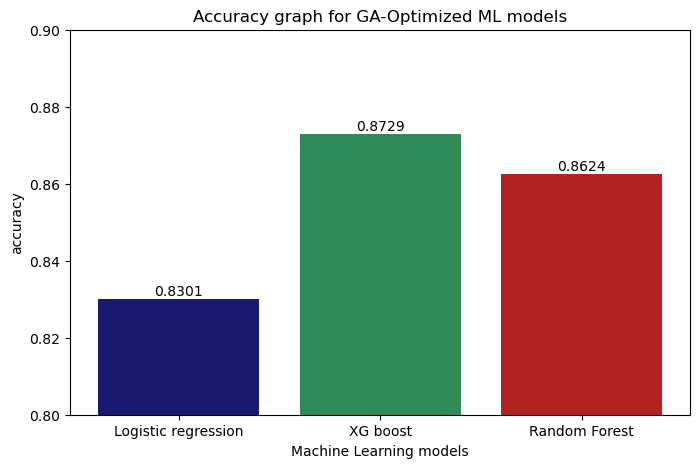

In [45]:
#accuracy graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))   #(width,height)
plt.bar(
    final_comparison["Model"],
    final_comparison["accuracy"],
    color= ["midnightblue", "seagreen", "firebrick"]
)
plt.title("Accuracy graph for GA-Optimized ML models")
plt.xlabel("Machine Learning models")
plt.ylabel("accuracy")
plt.ylim(0.80,0.90)       #Y-axis interval
for i, value in enumerate(final_comparison["accuracy"]): #writes value above the bar
    plt.text(
        i,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )
plt.show()
    

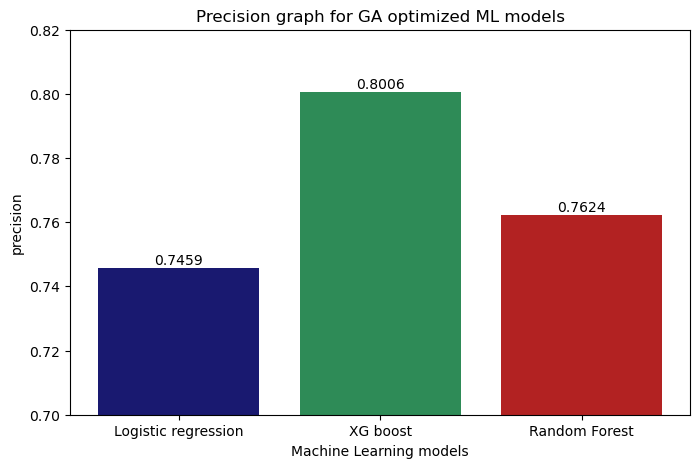

In [46]:
#precision graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    final_comparison["Model"],
    final_comparison["precision"],
    color= ["midnightblue", "seagreen", "firebrick"]
)
plt.title("Precision graph for GA optimized ML models")
plt.xlabel("Machine Learning models")
plt.ylabel("precision")
plt.ylim(0.70,0.82)
for i,value in enumerate(final_comparison["precision"]):
    plt.text(
         i,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )
plt.show()
        

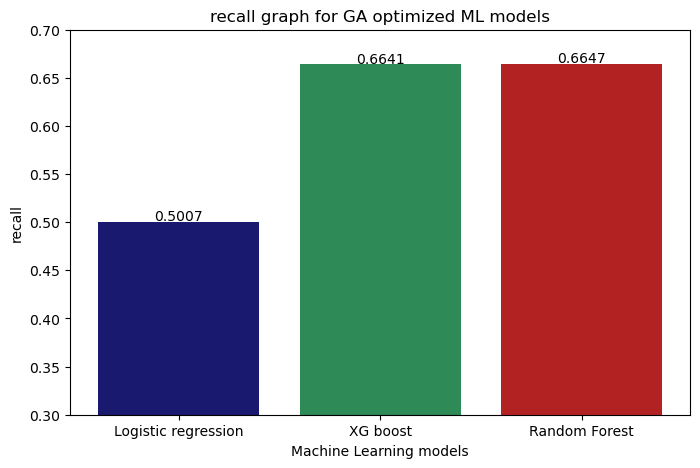

In [47]:
#recall graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    final_comparison["Model"],
    final_comparison["recall"],
    color= ["midnightblue", "seagreen", "firebrick"]
)
plt.title("recall graph for GA optimized ML models")
plt.xlabel("Machine Learning models")
plt.ylabel("recall")
plt.ylim(0.30,0.70)
for i,value in enumerate(final_comparison["recall"]):
    plt.text(
         i,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )
plt.show()

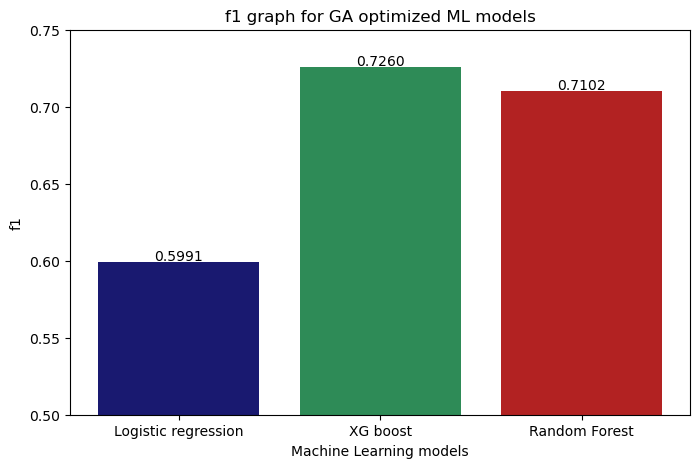

In [48]:
#f1 graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    final_comparison["Model"],
    final_comparison["f1"],
    color= ["midnightblue", "seagreen", "firebrick"]
)
plt.title("f1 graph for GA optimized ML models")
plt.xlabel("Machine Learning models")
plt.ylabel("f1")
plt.ylim(0.50,0.75)
for i,value in enumerate(final_comparison["f1"]):
    plt.text(
         i,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )
plt.show()

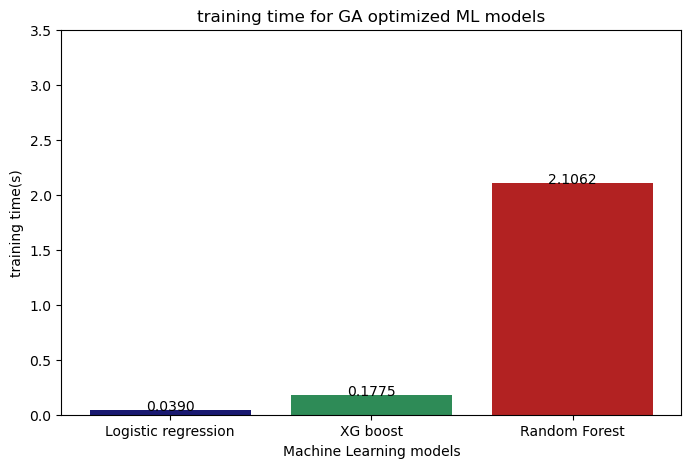

In [49]:
#training time
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    final_comparison["Model"],
    final_comparison["training time(s)"],
    color= ["midnightblue", "seagreen", "firebrick"]
)
plt.title("training time for GA optimized ML models")
plt.xlabel("Machine Learning models")
plt.ylabel("training time(s)")
plt.ylim(0.00,3.5)
for i,value in enumerate(final_comparison["training time(s)"]):
    plt.text(
         i,
        value+0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )
plt.show()

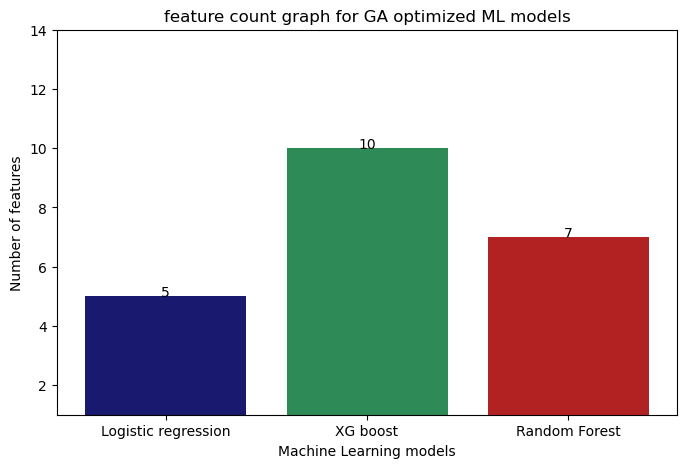

In [50]:
#feature count graph
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(
    final_comparison["Model"],
    final_comparison["no.of features"],
    color= ["midnightblue", "seagreen", "firebrick"]
)
plt.title("feature count graph for GA optimized ML models")
plt.xlabel("Machine Learning models")
plt.ylabel("Number of features")
plt.ylim(1,14)
for i,value in enumerate(final_comparison["no.of features"]):
    plt.text(
         i,
        value+0.001,
        f"{value:.0f}",
        ha="center",
        fontsize=10
    )
plt.show()

In [51]:
#imports for confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

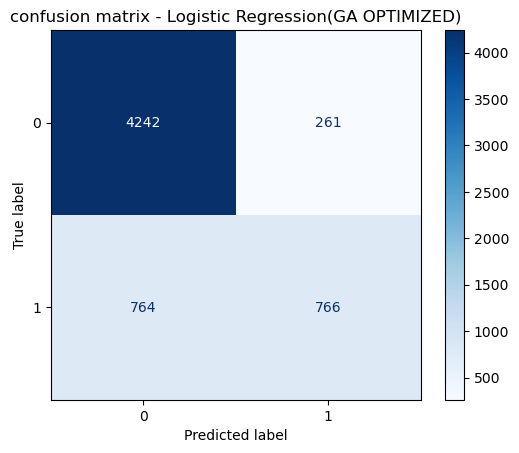

In [52]:
#confusion matrix for logistic regression
ConfusionMatrixDisplay.from_predictions(
     y_test,
     lr_optimized_predictions,
     cmap="Blues" 
 )
plt.title("confusion matrix - Logistic Regression(GA OPTIMIZED)")
plt.show()

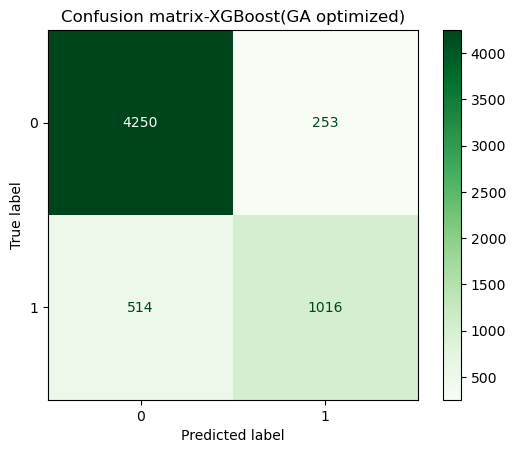

In [53]:
#confusion matrix for xgboost
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_optimized_predictions,
    cmap="Greens"
)
plt.title("Confusion matrix-XGBoost(GA optimized)")
plt.show()

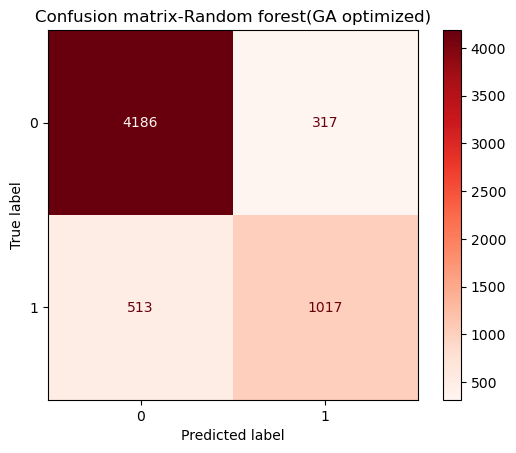

In [54]:
#confusion matrix for random forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_optimized_predictions,
    cmap="Reds"
)
plt.title("Confusion matrix-Random forest(GA optimized)")
plt.show()


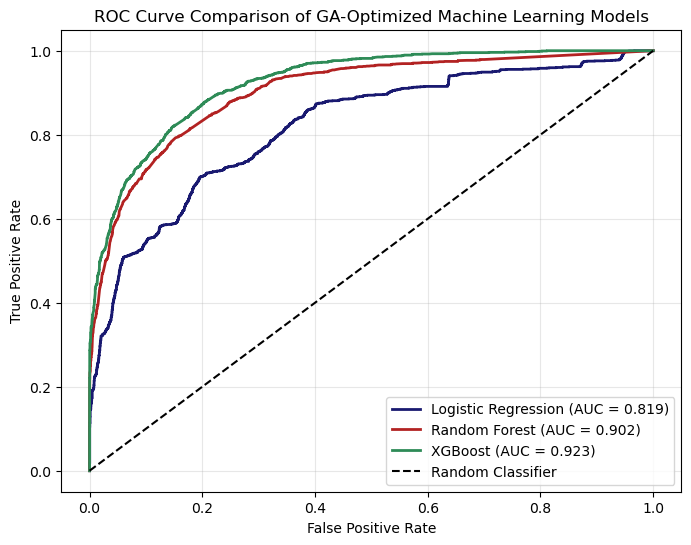

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
lr_prob = lr_optimized_model.predict_proba(x_test_lr_ga)[:,1]
rf_prob = rf_optimized_model.predict_proba(x_test_rf)[:,1]
xgb_prob = xgb_optimized_model.predict_proba(x_test_xgb)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
xgb_auc = roc_auc_score(y_test, xgb_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    color="midnightblue",
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    color="firebrick",
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    color="seagreen",
    linewidth=2,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison of GA-Optimized Machine Learning Models")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

## Conclusion

This project presented a comparative analysis of three ML algorithms—Logistic Regression, Random Forest, and XGBoost—for predicting income using the Adult Income Census dataset. A Genetic Algorithm (GA) was applied for feature selection to identify the most relevant attributes and improve model performance.

The performance of the models was evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC. Hyperparameter tuning was also performed and compared with the GA-based feature selection approach.

Experimental results showed that Genetic Algorithm-based feature selection produced better overall model performance than hyperparameter tuning. While hyperparameter tuning occasionally increased accuracy, the GA approach achieved a better balance of evaluation metrics and reduced the feature set, making the models more efficient without compromising predictive performance.

Among all the models, the GA-optimized **XGBoost classifier** achieved the best overall performance with an accuracy of approximately **87.29%**, along with strong Precision, Recall, and F1 Score. The results demonstrated that Genetic Algorithm-based feature selection effectively reduced the number of features while maintaining or improving predictive performance.

Overall, this project highlights the importance of feature selection in machine learning and shows that combining Genetic Algorithms with ensemble learning methods such as XGBoost can produce robust and efficient classification models for real-world datasets.
